# Laboratorio 3 — Clasificación binaria (Regresión logística)

**Dataset:** `CICIoT2023_xsmall.csv`

**Objetivo:** clasificar tráfico **benigno (0)** vs **ataque (1)** usando regresión logística.

**Requisitos del enunciado (aquí):**
- Se usan $m\ge 20000$ ejemplos y $n\ge 20$ propiedades (features numéricas).
- Preprocesamiento con **Pandas**.
- Validación con **80% train / 20% test** (sin usar test durante el entrenamiento).




In [4]:
# Instala SciPy en el kernel actual (necesario para optimize.minimize del inge)
%pip -q install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# Librería para manipulación y preprocesamiento de datos
import pandas as pd

## 1) Carga y preprocesamiento

- Se lee el CSV por bloques para no cargar todo en memoria.
- Se construye `y` binaria desde la columna `label`.
- Se seleccionan **20 columnas numéricas** y se imputan valores faltantes con la mediana.
- Se aplica **split estratificado 80/20** y **escalado** usando solo el set de entrenamiento.


In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv("CICIoT2023_xsmall.csv")

# convertir label a binario
df["label"] = df["label"].astype(str).str.lower()
df["label"] = df["label"].apply(lambda x: 0 if "benign" in x else 1)

# separar datos
X = df.drop("label", axis=1)
y = df["label"]

# convertir a números
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

X = X.to_numpy()
y = y.to_numpy()

print(np.unique(y))

[0 1]


### Visualización rápida

Scatter usando solo 2 features (solo para visualizar). El modelo se entrena con $n\ge 20$ features.


In [28]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=5)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=4, mec='k', mew=1)

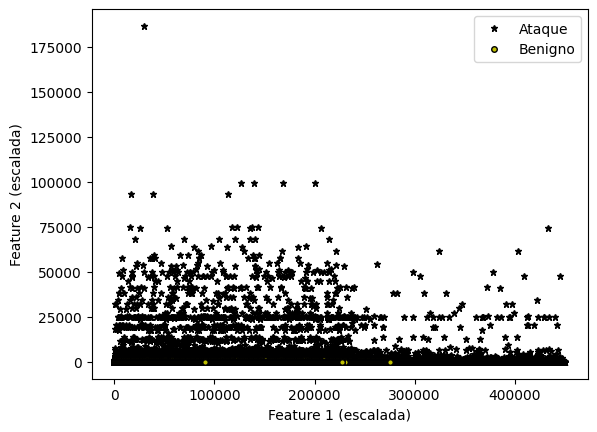

In [29]:
# Visualización (solo 2 features para el scatter)
# Nota: el modelo se entrena con n>=20 (arriba), esto es solo para ver la nube.
X_vis = X[:, :2]
plotData(X_vis, y)
pyplot.xlabel('Feature 1 (escalada)')
pyplot.ylabel('Feature 2 (escalada)')
pyplot.legend(['Ataque', 'Benigno'])
pass
pyplot.show() 

## 2) Función sigmoide

Implementación de `sigmoid(z)` con una pequeña estabilización numérica para evitar overflow.


In [14]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    # Estabilización numérica para evitar overflow en exp
    z = np.clip(z, -500, 500)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g


In [15]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


## 3) Costo y gradiente (train)

Se define la función de costo (entropía cruzada binaria) y el descenso por gradiente.
Antes de entrenar se agrega la columna de 1s (intercepto) a `X` y `X_test`.


In [65]:
# Agregar el término de intercepción (columna de 1s) a train y test
m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

m_test = X_test.shape[0]
X_test = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)


## 4) Entrenamiento

- Caso A: **Descenso por gradiente** (se grafica el costo por iteración).
- Caso B: **Optimización con `scipy.optimize.minimize`** para estimar `theta`.


In [66]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))

    # Evitar log(0)
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J


In [67]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

theta calculado por el descenso por el gradiente: [-2.69543501e-06 -2.09600770e-02 -2.13102206e-02 -1.93626898e-02
 -2.60401670e-02  2.49707719e-03  2.49707719e-03  4.59546707e-02
 -3.07214419e-04  4.59546707e-02 -4.24315969e-03 -3.91831913e-02
  4.44848821e-02 -2.68442997e-02  4.38686370e-02 -2.06570714e-02
 -2.34894716e-02  3.62331810e-03 -3.01044948e-02 -1.50684849e-03
  1.30009780e-02]


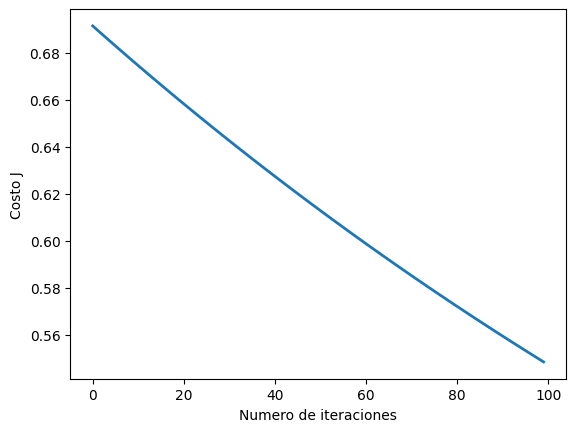

In [68]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 100

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n+1)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

## 5) Optimización con SciPy

Se usa `optimize.minimize` sobre el conjunto de entrenamiento para encontrar `theta`.


In [69]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos X y Y en una nueva figura con un limite de desicion definido por theta.
    """
    theta = np.array(theta)

    # Graficar los datos (recordar que la primera columna en X es la intercepción)
    plotData(X[:, 1:3], y)

    if X.shape[1] <= 3:
        # Solo se requieren 2 puntos para definir una linea, para lo cual se eligen dos puntos finales
        plot_x = np.array([np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1])

        # Calcular la línea límite de decisión
        plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

        pyplot.plot(plot_x, plot_y)

        pyplot.xlim([plot_x[0], plot_x[1]])
        ymin = np.min(X[:, 2]) - 1
        ymax = np.max(X[:, 2]) + 1
        pyplot.ylim([ymin, ymax])
        pyplot.legend(['Ataque', 'Benigno', 'Limite de decisión'])
    else:
        pass

In [70]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    # Evitar log(0)
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

# Establecer las opciones para optimize.minimize (TNC usa maxfun)
options= {'maxfun': 200}

# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n+1)

# Se utiliza el algoritmo de Newton truncado para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

# la propiedad fun del objeto devuelto por `OptimizeResult` contiene el valor del costFunction
cost = res.fun

# Theta optimizada esta en la propiedad x
theta = res.x

# Imprimir theta en la pantalla
print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost))
print('theta:', theta)


Costo con un valor de theta encontrado por optimize.minimize: 0.003
theta: [ 2.36038088 -3.04253184  2.78907228 -0.10197551 -0.07677951 -0.05373859
 -0.05373859  6.68759825 -0.10860934  6.68759825 -2.18824103  2.57570776
 -1.07246824  0.23133854  0.46050147  0.5400792  -4.971998   -0.34364836
 -1.00322634 -0.63170217 -1.42715991]


## 6) Validación (train vs test)

Se generan predicciones y se reporta exactitud (accuracy) y matriz de confusión en **test**.


In [71]:
# Graficar límites (solo aplica si el modelo tiene 2 features + intercepto)
if X.shape[1] <= 3:
    plotDecisionBoundary(plotData, theta, X, y)
else:
    print('Omitido: la frontera de decisión solo se grafica con 2 features.')


Omitido: la frontera de decisión solo se grafica con 2 features.


In [72]:
def predict(theta, X):
    """Predice 0/1 usando umbral 0.5."""
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Evaluación en train y test
p_train = predict(theta, X)
p_test = predict(theta, X_test)

acc_train = np.mean(p_train == y) * 100
acc_test = np.mean(p_test == y_test) * 100

print('Precisión train: {:.2f} %'.format(acc_train))
print('Precisión test : {:.2f} %'.format(acc_test))

# Matriz de confusión (test)
tp = int(np.sum((p_test == 1) & (y_test == 1)))
tn = int(np.sum((p_test == 0) & (y_test == 0)))
fp = int(np.sum((p_test == 1) & (y_test == 0)))
fn = int(np.sum((p_test == 0) & (y_test == 1)))

print('Confusión (test)')
print('TN:', tn, 'FP:', fp)
print('FN:', fn, 'TP:', tp)


Precisión train: 99.96 %
Precisión test : 99.93 %
Confusión (test)
TN: 3000 FP: 0
FN: 4 TP: 2996
